# A3 후속: steering 강도 및 C+/C− 비율 분석
기존 A3(ρ=0.06)의 방향·질문·프롬프트·레이어·채점은 고정하고 **A0 강도만** 바꾼다.
외부 데이터 결과를 이미 확인한 후속 **탐색 실험**이다. 이 결과에서 가장 좋은 강도를 선택한 뒤 같은 데이터에서 확증됐다고 주장하지 않는다.

- 기본 강도: 0, .01, .02, .03, .04, .05, .06, .08
- C− 비율: 0%, 1%, 5%, 10%, 20%, 25%, 30%, 50%, 70%, 90%, 100%
- 0/.06 및 closed-book은 A3 결과 재사용. 나머지 6개 강도만 생성한다.
- 비율 분석은 동일한 질문 쌍의 성능을 재가중한다. 새로운 문맥/질문 분포 자체를 검증하는 것은 아니다.
- E16 confidence 중재는 포함하지 않는다. 강도 효과와 정책 효과를 분리한다.
- 노트북과 같은 폴더의 result/A3_sweep_<UTC>/에 저장한다. 실패 결과를 보존하며 자동 resume는 지원하지 않는다.


In [1]:
%pip install -q "transformers==5.17.0" "accelerate==1.14.0" numpy pandas pyarrow matplotlib requests huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 8.6 MB/s eta 0:00:00


설치 후 런타임을 재시작하고 아래부터 실행한다. 기존 A3의 torch·transformers 버전과 일치하지 않으면 생성 전에 중단한다.

In [4]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

# 이 노트북을 업로드한 실제 Drive 폴더로 수정한다.
PROJECT_DIR = Path('/content/drive/MyDrive/12주차_실험_다영')
SOURCE_RUN = Path('/content/drive/MyDrive/12주차_실험_다영/result/20261004T085540433485Z')
P9 = Path('/content/drive/MyDrive/11주차_A축_실험_다영/P9')
ANALYSIS_ONLY = False  # True: GPU 생성 없이 기존 0/.06의 비율별 결과만 분석
CFG = dict(project_dir=str(PROJECT_DIR), source_run=str(SOURCE_RUN), p9=str(P9),
    analysis_only=ANALYSIS_ONLY, datasets=['p8s_dev','nqswap','confiqa_qa'],
    rhos=[0.,.01,.02,.03,.04,.05,.06,.08],
    Cminus_ratios=[0.,.01,.05,.10,.20,.25,.30,.50,.70,.90,1.],
    batch_size=8, bootstrap_repeats=4000)
assert (PROJECT_DIR/'A3-1_Strength_and_Mixture.ipynb').is_file(), '노트북 파일이 있는 폴더로 PROJECT_DIR을 수정한다.'
assert SOURCE_RUN.is_dir(), '기존 A3 result 실행 폴더를 확인한다.'
print('기존 실행 환경:', (SOURCE_RUN/'environment.json').read_text())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
기존 실행 환경: {
  "torch": "2.11.0+cu130",
  "transformers": "5.17.0",
  "model": "meta-llama/Llama-3.1-8B-Instruct",
  "revision": "0e9e39f249a16976918f6564b8830bc894c89659",
  "gpu": "NVIDIA A100-SXM4-40GB",
  "dtype": "torch.bfloat16",
  "numpy": "2.1.3",
  "pandas": "2.2.3"
}


In [5]:
if not ANALYSIS_ONLY:
    from getpass import getpass
    from huggingface_hub import login
    if not os.environ.get('HF_TOKEN'):
        login(token=getpass('HF read token: ').strip(),add_to_git_credential=False)


HF read token: ··········


In [9]:
"""Always-steering evaluation. Embedded verbatim in the Colab notebook.
No model download/generation on import. External evaluation never fits directions.
"""
import contextlib
import datetime as dt
import hashlib
import importlib.util
import json
import os
import re
import time
import unicodedata
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd

NQ_REV = 'bc50bb161aa706bdf5f2e6a8ce082ac292231bc0'
CF_REV = '557dadeeb9f47407890a5626128ca99907770b22'
SOURCES = {
    'nqswap': f'https://huggingface.co/datasets/younanna/NQ-Swap/resolve/{NQ_REV}/data/dev-00000-of-00001.parquet',
    'confiqa_qa': f'https://raw.githubusercontent.com/byronBBL/Context-DPO/{CF_REV}/ConFiQA/ConFiQA-QA.json',
}
LAYERS = [14,15,16,17,18]
SEED = 20261004


def dump(path, obj):
    def cast(x):
        if isinstance(x, np.generic): return x.item()
        if isinstance(x, Path): return str(x)
        raise TypeError(type(x).__name__)
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=2, default=cast), encoding='utf-8')


def sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda:f.read(1<<20),b''): h.update(chunk)
    return h.hexdigest()


def question_key(q):
    # Conservative exact normalized text dedup; no claim of semantic/entity disjointness.
    return re.sub(r'\W+', ' ', unicodedata.normalize('NFKC',str(q)).casefold()).strip()


def norm(text):
    import string
    s=unicodedata.normalize('NFKC',str(text)).lower()
    s=''.join(c for c in s if c not in string.punctuation)
    return ' '.join(w for w in s.split() if w not in {'a','an','the'})


def answers(value):
    if isinstance(value,str): value=[value]
    if isinstance(value,np.ndarray): value=value.tolist()
    if not isinstance(value,(list,tuple)): raise ValueError(f'Answer field must be string/list, got {type(value)}')
    if any(not isinstance(x,str) for x in value): raise ValueError('Nested/non-string answer field')
    result=list(dict.fromkeys(x.strip() for x in value if norm(x)))
    if not result: raise ValueError('Empty gold answers')
    return result


def truncate(raw):
    s=str(raw).strip().split('\n')[0].strip()
    s=re.sub(r'^(answer|the answer is)\s*:?\s*','',s,flags=re.I)
    abbr=r'(?<!\bDr)(?<!\bMr)(?<!\bMs)(?<!\bMrs)(?<!\bSt)(?<!\bJr)(?<!\bSr)(?<!\b[A-Z])'
    if len(s.split())>8: s=re.split(abbr+r'\.\s+(?=[A-Z])',s)[0]
    return re.sub(r'[.,;:\s]+$','',s.strip().strip('"\u0027')).strip()


def token_f1(pred,gold):
    p,g=norm(pred).split(),norm(gold).split()
    if not p or not g: return float(p==g)
    common=sum((Counter(p)&Counter(g)).values())
    return 2.*common/(len(p)+len(g))


def score(pred,golds):
    golds=answers(golds)
    return int(any(norm(pred)==norm(g) for g in golds)), max(token_f1(pred,g) for g in golds)


def bootstrap(questions, delta, repeats=4000, seed=SEED):
    # Cluster by question: C+ and C- remain paired. Returns None for empty K/C cells.
    d=pd.DataFrame({'q':questions,'d':delta}).groupby('q').d.agg(['sum','count'])
    if not len(d): return dict(delta=None,lo=None,hi=None,n_questions=0)
    rng=np.random.default_rng(seed); draws=[]
    for start in range(0,repeats,100):
        ix=rng.integers(0,len(d),size=(min(100,repeats-start),len(d)))
        draws.extend((d['sum'].values[ix].sum(1)/d['count'].values[ix].sum(1)).tolist())
    lo,hi=np.percentile(draws,[2.5,97.5])
    return dict(delta=float(np.mean(delta)),lo=float(lo),hi=float(hi),n_questions=len(d))


def prop_direction(x,props,ret,acc,train,min_n=3):
    ds=[]
    for p in sorted(set(props[train])):
        a=train & ret & (props==p); b=train & acc & (props==p)
        if a.sum()>=min_n and b.sum()>=min_n: ds.append(x[a].mean(0)-x[b].mean(0))
    if not ds: raise ValueError('No property has enough retain/accept training samples')
    return unit(np.mean(ds,axis=0))


def unit(x):
    x=np.asarray(x,dtype=np.float64); n=np.linalg.norm(x,axis=-1,keepdims=True)
    if not np.isfinite(x).all() or (n<1e-8).any(): raise ValueError('Invalid direction')
    return (x/n).astype(np.float32)


def adapt_records(data,name):
    """Paired real-world-factuality task, NOT the original context-faithfulness leaderboard."""
    records=[]; exclusions=[]
    for i,r in enumerate(data):
        try:
            if name=='nqswap':
                if r.get('substitution_type')!='corpus': raise ValueError('Protocol: corpus substitutions only')
                q=r['question']; cp=r['original_context']; cm=r['substituted_context']
                gold=answers(r['original_answers']); false=answers(r['substituted_answers'])
            elif name=='confiqa_qa':
                q=r['question']; cp=r['orig_context']; cm=r['cf_context']
                gold=answers([r['orig_answer']]+list(r.get('orig_alias') or []))
                false=answers([r['cf_answer']]+list(r.get('cf_alias') or []))
            else: raise ValueError(name)
            if not all(isinstance(v,str) and v.strip() for v in [q,cp,cm]): raise ValueError('Empty text')
            if cp==cm: raise ValueError('Identical C+/C- context')
            if {norm(x) for x in gold}&{norm(x) for x in false}: raise ValueError('Gold/counterfactual alias overlap')
            key=question_key(q)
            if not key: raise ValueError('Empty question')
            records.append(dict(dataset=name,source_index=i,question=q,qkey=key,
                                cp=cp,cm=cm,gold=gold,counterfactual=false))
        except (KeyError,ValueError,TypeError) as e:
            exclusions.append(dict(dataset=name,source_index=i,reason=str(e)))
    if not records: raise ValueError(f'{name}: no records; check source schema')
    return records,exclusions


def select_pairs(records,excluded_keys,limit,seed=SEED):
    # Hash order independent of correctness, K labels, model outputs, and row sorting.
    ordered=sorted(records,key=lambda r:hashlib.sha256(f'{seed}:{r["qkey"]}:{r["source_index"]}'.encode()).hexdigest())
    seen=set(excluded_keys); selected=[]; log=[]
    for r in ordered:
        if r['qkey'] in seen:
            log.append(dict(dataset=r['dataset'],source_index=r['source_index'],reason='question overlap/duplicate'))
            continue
        seen.add(r['qkey'])
        if limit and len(selected)>=limit:
            log.append(dict(dataset=r['dataset'],source_index=r['source_index'],reason='predefined sample limit'))
            continue
        selected.append(r)
    return selected,log


def pair_rows(records):
    out=[]
    for r in records:
        for c in ['C+','C-']:
            out.append(dict(dataset=r['dataset'],qid=r['dataset']+':'+r['qkey'],question=r['question'],
                qkey=r['qkey'],C=c,context=r['cp' if c=='C+' else 'cm'],gold=r['gold'],
                context_answers=r['gold'] if c=='C+' else r['counterfactual'],source_index=r['source_index']))
    return pd.DataFrame(out)


class AlwaysHook:
    """All non-padding prefill tokens + decode; no C/K labels read at runtime."""
    def __init__(self,model,vectors,scales,attention_mask,strength=1.):
        self.model=model;self.vectors=vectors;self.scales=scales
        self.mask=attention_mask;self.strength=strength;self.handles=[];self.calls=Counter()
    def __enter__(self):
        try:
            for l in self.vectors:
                self.handles.append(self.model.model.layers[l].register_forward_hook(self.hook(l)))
        except BaseException:
            self.__exit__(None,None,None);raise
        return self
    def hook(self,l):
        def apply(mod,args,out):
            import torch
            self.calls[l]+=1
            if self.strength==0:return out
            h=out[0] if isinstance(out,(tuple,list)) else out
            v=torch.as_tensor(self.vectors[l],device=h.device,dtype=h.dtype)
            d=(self.scales[l]*self.strength*v).to(h.dtype)
            if h.shape[1]>1:
                if h.shape[:2]!=self.mask.shape:raise ValueError('Prefill mask mismatch')
                h+=self.mask.to(h.device,h.dtype)[:,:,None]*d
            else:h[:,-1,:]+=d
            return out
        return apply
    def __exit__(self,*args):
        for h in self.handles:h.remove()
        self.handles.clear()


class Runner:
    def __init__(self,model,tok,pp,max_tokens=192):
        self.model=model;self.tok=tok;self.pp=pp;self.max_tokens=max_tokens
        self.eos=sorted({tok.eos_token_id,tok.convert_tokens_to_ids("<|eot_id|>")}-{None})
    def prompt(self,q,context=None):
        msgs=self.pp.build_messages_cb(q) if context is None else self.pp.build_messages(q,context)
        return self.tok.apply_chat_template(msgs,tokenize=False,add_generation_prompt=True)
    def capture(self,prompt):
        import torch
        values={};hs=[]
        def hook(l):
            def f(m,a,o):
                x=o[0] if isinstance(o,(tuple,list)) else o
                values[l]=x[0,-1].detach().float().cpu().numpy().copy()
            return f
        try:
            for l in LAYERS:hs.append(self.model.model.layers[l].register_forward_hook(hook(l)))
            enc=self.tok(prompt,return_tensors='pt',add_special_tokens=False).to(self.model.device)
            with torch.inference_mode():self.model.model(**enc,use_cache=False,return_dict=True)
            return np.stack([values[l] for l in LAYERS])
        finally:
            for h in hs:h.remove()
    def batch(self,prompts,vectors=None,scales=None,zero=False):
        import torch
        torch.cuda.synchronize();start=time.perf_counter();torch.cuda.reset_peak_memory_stats()
        enc=self.tok(prompts,return_tensors='pt',padding=True,add_special_tokens=False).to(self.model.device)
        counter={'n':0}
        def count(m,a):counter['n']+=1
        handle=self.model.register_forward_pre_hook(count)
        edit=AlwaysHook(self.model,vectors,scales,enc.attention_mask,0. if zero else 1.) if vectors is not None else contextlib.nullcontext()
        try:
            with edit,torch.inference_mode():
                g=self.model.generate(**enc,max_new_tokens=self.max_tokens,do_sample=False,num_beams=1,
                    use_cache=True,pad_token_id=self.tok.pad_token_id,eos_token_id=self.eos)[:,enc.input_ids.shape[1]:]
            if counter['n']!=g.shape[1]:raise RuntimeError('Unexpected extra forward/generation backend')
        finally:handle.remove()
        torch.cuda.synchronize();elapsed=time.perf_counter()-start
        result=[]
        for row in g.cpu().tolist():
            stop=next((i for i,t in enumerate(row) if t in self.eos),None)
            n=len(row) if stop is None else stop
            raw=self.tok.decode(row[:n],skip_special_tokens=True,clean_up_tokenization_spaces=False)
            result.append(dict(raw=raw,n_tokens=n,hit_limit=int(stop is None and n>=self.max_tokens)))
        return result,dict(seconds=elapsed,rows=len(prompts),forward_calls=counter['n'],
            generated_tokens=sum(x['n_tokens'] for x in result),peak_bytes=torch.cuda.max_memory_allocated())
    def generate(self,frame,path,vectors=None,scales=None,batch_size=8,zero=False):
        result=[];audits=[]
        # Hash tie break, never sort by C label.
        order=frame.assign(tie=frame.rid.map(lambda r:hashlib.sha256(f'{SEED}:{r}'.encode()).hexdigest())).sort_values(['length','tie']).index.tolist()
        for start in range(0,len(order),batch_size):
            ids=order[start:start+batch_size]
            outs,audit=self.batch(frame.loc[ids,'prompt'].tolist(),vectors,scales,zero)
            result.extend(dict(rid=int(frame.loc[i,'rid']),**o) for i,o in zip(ids,outs))
            audits.append(audit)
            if path is not None:pd.DataFrame(result).to_parquet(path.with_suffix('.partial.parquet'),index=False)
            if start%(batch_size*20)==0:print('generate',str(path.name if path else 'check'),start,'/',len(order),flush=True)
        d=pd.DataFrame(result).sort_values('rid').reset_index(drop=True)
        if path is not None:
            d.to_parquet(path,index=False);dump(path.with_suffix('.audit.json'),audits)
        return d


def freeze_directions(runner,m,labels,H,saved,run,rho,include_ctx=True):
    """p8s-only fitting. ctx: official CB vs contextual prompt reconstruction, not team exact replication."""
    folds=m.fold.to_numpy();is_cm=m.C.eq('C-').to_numpy()
    props=labels.prop.to_numpy();ret=labels.ret_x.eq(1).to_numpy();acc=labels.acc_x.eq(1).to_numpy()
    if (ret&acc).any():raise ValueError('retain/accept overlap')
    x=np.stack([np.asarray(H[:,l],dtype=np.float32) for l in LAYERS],axis=1)
    # [n rows, 5 layers, hidden], only p8s activations, never external data.
    if include_ctx:
        cb={};ctx=np.empty_like(x)
        for i,row in m.iterrows():
            if row.question not in cb:cb[row.question]=runner.capture(runner.prompt(row.question))
            ctx[i]=runner.capture(row.prompt)
            if i%100==0:print('p8s calibration',i,'/',len(m),flush=True)
        diff=np.stack([cb[q] for q in m.question])-ctx
        np.savez_compressed(run/'p8s_ctx_calibration.npz',difference=diff)
    vectors={};scales={};cosines=[];manifest={}
    for fold in list(range(5))+['full']:
        train=np.ones(len(m),bool) if fold=='full' else folds!=fold
        train_questions=set(m.question[train]);test_questions=set() if fold=='full' else set(m.question[~train])
        if train_questions&test_questions:raise ValueError('Fold leakage')
        manifest[str(fold)]=dict(train_questions=sorted(train_questions),test_questions=sorted(test_questions))
        vectors[fold]={'A0':{}};scales[fold]={l:rho*float(np.median(np.linalg.norm(x[train,j],axis=1))) for j,l in enumerate(LAYERS)}
        for j,l in enumerate(LAYERS):
            u=prop_direction(x[:,j],props,ret,acc,train&is_cm)
            if fold!='full':
                ref=saved[f'w_f{fold}_L{l}'].astype(np.float32)
                cosine=float(u@ref/max(np.linalg.norm(ref),1e-12))
                if cosine<.9999:raise ValueError('A0 direction reconstruction mismatch')
                u=ref  # use exact frozen original directions for p8s OOF
            vectors[fold]['A0'][l]=u
        if include_ctx:
            uc=unit(diff[train].astype(np.float64).mean(0))
            vectors[fold]['CTX']={l:uc[j] for j,l in enumerate(LAYERS)}
            for j,l in enumerate(LAYERS):cosines.append(dict(fold=str(fold),layer=l,cos_A0=float(uc[j]@unit(vectors[fold]['A0'][l]))))
        np.savez(run/f'frozen_{fold}.npz',**{f'{a}_L{l}':v for a,vs in vectors[fold].items() for l,v in vs.items()},
                 **{f'scale_L{l}':s for l,s in scales[fold].items()})
    dump(run/'direction_fit_manifest.json',manifest)
    pd.DataFrame(cosines).to_csv(run/'direction_cosines.csv',index=False)
    return vectors,scales


def evaluate_tables(frame,gens,cb):
    cb_map=cb.set_index('qid').raw.to_dict()
    all_rows=[]
    for arm,g in gens.items():
        if set(g.rid)!=set(frame.rid) or g.rid.duplicated().any():raise ValueError('Output row mismatch')
        joined=frame.merge(g,on='rid',validate='one_to_one')
        for r in joined.itertuples():
            pred=truncate(r.raw);em,f1=score(pred,r.gold);raw_em,raw_f1=score(r.raw,r.gold)
            cb_em,_=score(truncate(cb_map[r.qid]),r.gold)
            grams=Counter(tuple(pred.split()[i:i+3]) for i in range(max(0,len(pred.split())-2)))
            all_rows.append(dict(dataset=r.dataset,rid=r.rid,qid=r.qid,question=r.question,C=r.C,
                K='K+' if cb_em else 'K-',arm=arm,raw=r.raw,pred=pred,EM=em,F1=f1,raw_EM=raw_em,raw_F1=raw_f1,
                context_match=score(pred,r.context_answers)[0],n_tokens=r.n_tokens,hit_limit=r.hit_limit,
                rep3=int(bool(grams) and max(grams.values())>=3)))
    return pd.DataFrame(all_rows)


def aggregate(rows,margin=-.02):
    metrics=[];comparisons=[]
    refs=['base','A0']
    for ds,d in rows.groupby('dataset'):
        for arm,a in d.groupby('arm'):
            masks={'ALL':np.ones(len(a),bool),'C+':a.C.eq('C+'),'C-':a.C.eq('C-')}
            masks.update({k+c:(a.K.eq(k)&a.C.eq(c)) for k in ['K+','K-'] for c in ['C+','C-']})
            for group,mask in masks.items():
                z=a.loc[mask]
                metrics.append(dict(dataset=ds,arm=arm,group=group,n=len(z),n_questions=z.qid.nunique(),
                    **{f:float(z[f].mean()) if len(z) else None for f in ['EM','F1','raw_EM','raw_F1','context_match','hit_limit','rep3']}))
                for ref in refs:
                    if arm==ref or ref not in set(d.arm):continue
                    refrows=d[d.arm==ref][['rid','EM','F1']]
                    both=z.merge(refrows,on='rid',suffixes=('','_ref'),validate='one_to_one')
                    for metric in ['EM','F1']:
                        ci=bootstrap(both.qid,both[metric]-both[metric+'_ref'])
                        comparisons.append(dict(dataset=ds,arm=arm,reference=ref,group=group,metric=metric,**ci,
                            recovery=int(((both.EM==1)&(both.EM_ref==0)).sum()),
                            damage=int(((both.EM==0)&(both.EM_ref==1)).sum()),
                            Cplus_noninferior=bool(ci['lo'] is not None and ci['lo']>=margin) if group=='C+' and metric=='EM' else None))
    return pd.DataFrame(metrics),pd.DataFrame(comparisons)


def plots(run,metrics,comparisons):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    for ds,d in metrics.groupby('dataset'):
        groups=['ALL','C+','C-','K+C+','K+C-','K-C+','K-C-'];arms=list(d.arm.unique())
        fig,axes=plt.subplots(1,2,figsize=(15,5))
        for ax,metric in zip(axes,['EM','F1']):
            for j,arm in enumerate(arms):
                vals=d[d.arm==arm].set_index('group').reindex(groups)[metric].astype(float)*100
                ax.bar(np.arange(len(groups))+(j-(len(arms)-1)/2)*.23,vals,.23,label=arm)
            ax.set(xticks=np.arange(len(groups)),xticklabels=groups,ylabel=f'{metric} (%)',ylim=(0,100),title=ds)
            ax.tick_params(axis='x',rotation=30);ax.legend()
        fig.tight_layout();fig.savefig(run/f'{ds}_metrics.png',dpi=180);plt.close(fig)
        c=comparisons[(comparisons.dataset==ds)&(comparisons.reference=='base')&(comparisons.metric=='EM')]
        fig,ax=plt.subplots(figsize=(10,6));y=0
        ticks=[];labels=[]
        for _,r in c.iterrows():
            if pd.isna(r.delta):continue
            ax.hlines(y,100*r.lo,100*r.hi,color='C0');ax.plot(100*r.delta,y,'o',color='C0')
            ticks.append(y);labels.append(r.arm+' '+r.group);y+=1
        ax.axvline(0,color='gray',ls='--');ax.set(yticks=ticks,yticklabels=labels,xlabel='EM delta vs base (pp), pointwise 95% CI',title=ds)
        fig.tight_layout();fig.savefig(run/f'{ds}_delta_ci.png',dpi=180);plt.close(fig)


def benchmark(runner,frame,vectors,scales,run,repeats=3):
    """Separate bs1 latency and bs8 throughput. Fixed query subset, warmed, order alternates."""
    sample=frame.assign(bench_key=frame.qid.map(lambda x:hashlib.sha256(f'{SEED}:bench:{x}'.encode()).hexdigest())).sort_values(['bench_key','rid']).head(64)
    specs=[('base',None,None)]+[(a,v,scales) for a,v in vectors.items()]
    runner.batch(sample.prompt.iloc[:1].tolist())
    for _,v,s in specs:runner.batch(sample.prompt.iloc[:1].tolist(),v,s)
    records=[]
    for bs in [1,8]:
        for rep in range(repeats):
            order=specs if rep%2==0 else specs[::-1]
            for arm,v,s in order:
                for start in range(0,len(sample),bs):
                    out,audit=runner.batch(sample.prompt.iloc[start:start+bs].tolist(),v,s)
                    records.append(dict(dataset=frame.dataset.iloc[0],mode=f'bs{bs}',repeat=rep,arm=arm,**audit))
    raw=pd.DataFrame(records);raw.to_csv(run/f'{frame.dataset.iloc[0]}_timing_raw.csv',index=False)
    summary=[]
    for (mode,arm),g in raw.groupby(['mode','arm']):
        summary.append(dict(dataset=frame.dataset.iloc[0],mode=mode,arm=arm,ms_per_row=1000*g.seconds.sum()/g.rows.sum(),
            rows_per_second=g.rows.sum()/g.seconds.sum(),tokens_per_second=g.generated_tokens.sum()/g.seconds.sum(),
            mean_output_tokens=g.generated_tokens.sum()/g.rows.sum(),peak_bytes=int(g.peak_bytes.max())))
    d=pd.DataFrame(summary)
    for mode in d['mode'].unique():
        b=float(d[(d['mode']==mode)&(d.arm=='base')].ms_per_row.iloc[0])
        d.loc[d['mode']==mode,'ratio_to_base']=d.loc[d['mode']==mode,'ms_per_row']/b
    d.to_csv(run/f'{frame.dataset.iloc[0]}_timing.csv',index=False)
    return d


"""A3 strength-only exploratory follow-up. Base evaluation helpers are embedded in notebook."""
import traceback

def mixture_summary(rows, ratios, repeats=4000):
    """Resample question pairs, then reweight C strata; never pretend weighted rows are new observations."""
    out=[]
    for name,ds in rows.groupby('dataset'):
        for arm,a in ds.groupby('arm'):
            for metric in ['EM','F1']:
                p=a.pivot(index='qid',columns='C',values=metric).sort_index()
                b=ds[ds.arm.eq('base')].pivot(index='qid',columns='C',values=metric).reindex(p.index)
                if p[['C+','C-']].isna().any().any() or b[['C+','C-']].isna().any().any():
                    raise ValueError('Missing question pair')
                v=p[['C+','C-']].to_numpy();bv=b[['C+','C-']].to_numpy();d=v-bv
                rng=np.random.default_rng(SEED);boot=[]
                for start in range(0,repeats,100):
                    ix=rng.integers(0,len(p),(min(100,repeats-start),len(p)))
                    boot.append(d[ix].mean(axis=1))
                boot=np.concatenate(boot)
                for ratio in ratios:
                    weights=np.array([1-ratio,ratio]);lo,hi=np.quantile(boot@weights,[.025,.975])
                    out.append(dict(dataset=name,arm=arm,metric=metric,Cminus_ratio=ratio,
                        score=float(v.mean(0)@weights),base_score=float(bv.mean(0)@weights),
                        delta=float(d.mean(0)@weights),lo=float(lo),hi=float(hi),n_questions=len(p)))
    return pd.DataFrame(out)


def reports(rows,run,ratios,repeats=4000):
    import matplotlib.pyplot as plt
    metrics,comp=aggregate(rows)
    metrics.to_csv(run/'metrics.csv',index=False);comp.to_csv(run/'comparisons.csv',index=False)
    mix=mixture_summary(rows,ratios,repeats);mix.to_csv(run/'mixture_metrics.csv',index=False)
    breaks=[]
    for name,ds in rows.groupby('dataset'):
        vals=ds.groupby(['arm','C']).EM.mean().unstack()
        for arm in vals.index:
            if arm=='base':continue
            dp,dm=(vals.loc[arm]-vals.loc['base'])[['C+','C-']]
            slope=dm-dp;cross=None if abs(slope)<1e-12 else float(-dp/slope)
            breaks.append(dict(dataset=name,arm=arm,delta_Cplus=dp,delta_Cminus=dm,
                crossing_Cminus_ratio=cross if cross is not None and 0<=cross<=1 else None,
                positive_at_Cminus_0=bool(dp>0),positive_at_Cminus_1=bool(dm>0),
                note='Point estimate only; crossing is not a confidence bound'))
        fig,axes=plt.subplots(1,2,figsize=(11,4))
        sub=metrics[(metrics.dataset==name)&metrics.group.isin(['C+','C-'])].copy()
        sub['rho']=sub.arm.map(lambda x:0. if x=='base' else float(x.split('rho')[1]))
        for c in ['C+','C-']:
            v=sub[sub.group==c].sort_values('rho');axes[0].plot(v.rho,v.EM*100,'o-',label=c)
        axes[0].set(xlabel='Steering strength rho',ylabel='EM (%)',title=name+' | strength');axes[0].legend()
        for arm,v in mix[(mix.dataset==name)&(mix.metric=='EM')&(~mix.arm.eq('base'))].groupby('arm'):
            v=v.sort_values('Cminus_ratio');axes[1].plot(v.Cminus_ratio*100,v.delta*100,label=arm)
        axes[1].axhline(0,color='gray',ls='--');axes[1].set(xlabel='C- share (%)',ylabel='EM difference vs base (pp)',title='Reweighted population; fixed question set')
        axes[1].legend(fontsize=8);fig.tight_layout();fig.savefig(run/f'{name}_strength_mixture.png',dpi=180);plt.close(fig)
        h=mix[(mix.dataset==name)&(mix.metric=='EM')&(~mix.arm.eq('base'))].pivot(index='arm',columns='Cminus_ratio',values='delta').sort_index()
        fig,ax=plt.subplots(figsize=(11,4));bound=max(.001,float(np.abs(h.to_numpy()).max()))
        im=ax.imshow(h.to_numpy()*100,aspect='auto',cmap='RdBu',vmin=-bound*100,vmax=bound*100)
        ax.set_xticks(range(len(h.columns)),[f'{r*100:g}' for r in h.columns]);ax.set_yticks(range(len(h.index)),h.index)
        ax.set(xlabel='C- share (%)',title=name+' | EM difference vs base (pp)')
        fig.colorbar(im,ax=ax);fig.tight_layout();fig.savefig(run/f'{name}_heatmap.png',dpi=180);plt.close(fig)
    pd.DataFrame(breaks).to_csv(run/'break_even.csv',index=False)
    return metrics,comp,mix


def run_sweep(cfg):
    source=Path(cfg['source_run']).expanduser().resolve();project=Path(cfg['project_dir']).expanduser().resolve()
    if not (project/'A3-1_Strength_and_Mixture.ipynb').is_file() and not (project/'A3_Strength_and_Mixture.ipynb').is_file():
        raise FileNotFoundError('PROJECT_DIR must contain this notebook')
    rhos=list(cfg['rhos']);ratios=list(cfg['Cminus_ratios'])
    if len(set(rhos))!=len(rhos) or not {0.,.06}.issubset(rhos) or any(not np.isfinite(x) or x<0 for x in rhos):raise ValueError('Invalid rho grid; include 0 and .06')
    if any(not 0<=r<=1 for r in ratios):raise ValueError('Ratios must be in [0,1]')
    protocol=json.loads((source/'protocol.json').read_text());env=json.loads((source/'environment.json').read_text())
    if json.loads((source/'status.json').read_text())['status']!='complete':raise ValueError('A3 source run not complete')
    if protocol['rho']!=.06 or protocol['layers']!=LAYERS:raise ValueError('Unexpected source intervention')
    run=project/'result'/('A3_sweep_'+dt.datetime.now(dt.timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'));run.mkdir(parents=True,exist_ok=False)
    dump(run/'status.json',dict(status='running'));dump(run/'protocol.json',dict(**cfg,
        study='A3 strength-only exploratory follow-up; existing external outcomes have been seen',
        intervention='A0 only. Frozen original directions and scales, scaled by rho/.06; same folds and rows',
        mixture='Cminus_ratio is population weight, not number of newly sampled examples',
        inference='pointwise paired question bootstrap; no correction for strength or ratio selection; no confirmatory best-arm claim',
        confidence='Not implemented; E16 specification pending',source_environment=env))
    try:
        source_rows=pd.read_parquet(source/'all_scored_rows.parquet')
        frames={name:pd.read_parquet(source/f'{name}_manifest.parquet') for name in cfg['datasets']}
        kept=[];hashes={}
        for name,frame in frames.items():
            if frame.rid.duplicated().any() or not frame.groupby('qid').C.apply(lambda x:sorted(x)==['C+','C-']).all():raise ValueError('Invalid paired manifest')
            for arm,label in [('base','base'),('A0','A0_rho0.06')]:
                z=source_rows[(source_rows.dataset==name)&(source_rows.arm==arm)].copy()
                expected=frame[['rid','qid','C']].sort_values('rid').reset_index(drop=True)
                actual=z[['rid','qid','C']].sort_values('rid').reset_index(drop=True)
                if not expected.equals(actual):raise ValueError('Cached results and manifest disagree')
                z['arm']=label;kept.append(z)
            for p in [source/f'{name}_manifest.parquet',source/name/'closed_book.parquet']:
                hashes[str(p)]=sha(p)
        hashes[str(source/'all_scored_rows.parquet')]=sha(source/'all_scored_rows.parquet')
        for key in [*range(5),'full']:hashes[str(source/f'frozen_{key}.npz')]=sha(source/f'frozen_{key}.npz')
        dump(run/'source_hashes.json',hashes)
        rows=pd.concat(kept,ignore_index=True)
        if cfg['analysis_only']:
            reports(rows,run,ratios,cfg['bootstrap_repeats'])
        else:
            import torch,transformers
            if not torch.cuda.is_available():raise RuntimeError('CUDA GPU required')
            if transformers.__version__!=env['transformers'] or torch.__version__!=env['torch']:
                raise RuntimeError('Use source torch/transformers versions: '+str({k:env[k] for k in ['torch','transformers']}))
            sv=Path(cfg['p9'])/'steer_v3';prompt=sv/'code/p8s_prompt.py'
            if hashlib.md5(prompt.read_bytes()).hexdigest()!='20959a4c34203ea0866d030baf23595d':raise ValueError('Prompt module changed')
            spec=importlib.util.spec_from_file_location('a3_frozen_prompt',prompt);pp=importlib.util.module_from_spec(spec);spec.loader.exec_module(pp)
            if pp.MODEL_ID!=env['model'] or pp.MAX_NEW_TOKENS!=192:raise ValueError('Source model/generation mismatch')
            torch.manual_seed(SEED);np.random.seed(SEED);torch.use_deterministic_algorithms(True,warn_only=True)
            torch.backends.cuda.matmul.allow_tf32=False;torch.backends.cudnn.allow_tf32=False;torch.backends.cudnn.benchmark=False
            from transformers import AutoTokenizer,AutoModelForCausalLM
            tok=AutoTokenizer.from_pretrained(env['model'],revision=env['revision']);tok.padding_side='left'
            if tok.pad_token is None:tok.pad_token=tok.eos_token
            model=AutoModelForCausalLM.from_pretrained(env['model'],revision=env['revision'],dtype=torch.bfloat16,device_map='auto',attn_implementation='sdpa').eval()
            runner=Runner(model,tok,pp,192)
            dump(run/'environment.json',dict(torch=torch.__version__,transformers=transformers.__version__,model=env['model'],revision=env['revision'],gpu=torch.cuda.get_device_name(0)))
            for name,frame in frames.items():
                if [runner.prompt(r.question,r.context) for r in frame.itertuples()]!=frame.prompt.tolist():raise ValueError('Manifest prompt mismatch')
                if [len(tok(p,add_special_tokens=False).input_ids) for p in frame.prompt]!=frame.length.tolist():raise ValueError('Token length mismatch')
                # Reproduce the original first batch before reusing its outputs across runs.
                check_fold=0 if name=='p8s_dev' else 'full'
                check_frame=frame[frame.fold==0] if name=='p8s_dev' else frame
                size=16 if name=='p8s_dev' else cfg['batch_size']
                order=check_frame.assign(tie=check_frame.rid.map(lambda r:hashlib.sha256(f'{SEED}:{r}'.encode()).hexdigest())).sort_values(['length','tie'])
                check=order.iloc[:size]
                with np.load(source/f'frozen_{check_fold}.npz') as z:
                    vv={l:z[f'A0_L{l}'].copy() for l in LAYERS};ss={l:float(z[f'scale_L{l}']) for l in LAYERS}
                checks={}
                for method in ['base','A0']:
                    actual,_=runner.batch(check.prompt.tolist(),vv if method=='A0' else None,ss if method=='A0' else None)
                    reference=source_rows[(source_rows.dataset==name)&(source_rows.arm==method)].set_index('rid')
                    checks[method]=sum(x['raw']!=reference.loc[r,'raw'] for r,x in zip(check.rid,actual))
                dump(run/f'{name}_reuse_check.json',checks)
                if any(checks.values()):raise RuntimeError('Original first batch did not reproduce; inspect reuse_check. Do not mix runs blindly.')
                dsdir=run/name;dsdir.mkdir();cb=pd.read_parquet(source/name/'closed_book.parquet')
                for rho in rhos:
                    if rho in [0.,.06]:continue
                    label=f'A0_rho{rho:g}';pieces=[]
                    for fold in (range(5) if name=='p8s_dev' else ['full']):
                        part=frame[frame.fold==fold] if name=='p8s_dev' else frame
                        with np.load(source/f'frozen_{fold}.npz') as frozen:
                            vectors={l:frozen[f'A0_L{l}'].copy() for l in LAYERS}
                            scales={l:float(frozen[f'scale_L{l}'])*rho/.06 for l in LAYERS}
                        pieces.append(runner.generate(part,dsdir/f'{label}_fold{fold}.parquet',vectors,scales,batch_size=16 if name=='p8s_dev' else cfg['batch_size']))
                    g=pd.concat(pieces).sort_values('rid').reset_index(drop=True);g.to_parquet(dsdir/f'{label}.parquet',index=False)
                    kept.append(evaluate_tables(frame,{label:g},cb));rows=pd.concat(kept,ignore_index=True)
                    rows.to_parquet(run/'all_scored_rows.parquet',index=False)
                    print('completed',name,label,flush=True)
            reports(rows,run,ratios,cfg['bootstrap_repeats'])
        rows.to_parquet(run/'all_scored_rows.parquet',index=False)
        dump(run/'status.json',dict(status='complete',analysis_only=cfg['analysis_only']));print('Complete:',run);return run
    except BaseException:
        dump(run/'status.json',dict(status='failed',traceback=traceback.format_exc()));print('Partial outputs:',run);raise

In [10]:
CFG['code_sha256'] = '1942ddf1dc4662bfbb51ef996ccc1ce5173a37aa33418ffe879bcb1d614c070a'
RUN = run_sweep(CFG)


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

generate A0_rho0.01_fold0.parquet 0 / 246
generate A0_rho0.01_fold1.parquet 0 / 246
generate A0_rho0.01_fold2.parquet 0 / 244
generate A0_rho0.01_fold3.parquet 0 / 244
generate A0_rho0.01_fold4.parquet 0 / 244
completed p8s_dev A0_rho0.01
generate A0_rho0.02_fold0.parquet 0 / 246
generate A0_rho0.02_fold1.parquet 0 / 246
generate A0_rho0.02_fold2.parquet 0 / 244
generate A0_rho0.02_fold3.parquet 0 / 244
generate A0_rho0.02_fold4.parquet 0 / 244
completed p8s_dev A0_rho0.02
generate A0_rho0.03_fold0.parquet 0 / 246
generate A0_rho0.03_fold1.parquet 0 / 246
generate A0_rho0.03_fold2.parquet 0 / 244
generate A0_rho0.03_fold3.parquet 0 / 244
generate A0_rho0.03_fold4.parquet 0 / 244
completed p8s_dev A0_rho0.03
generate A0_rho0.04_fold0.parquet 0 / 246
generate A0_rho0.04_fold1.parquet 0 / 246
generate A0_rho0.04_fold2.parquet 0 / 244
generate A0_rho0.04_fold3.parquet 0 / 244
generate A0_rho0.04_fold4.parquet 0 / 244
completed p8s_dev A0_rho0.04
generate A0_rho0.05_fold0.parquet 0 / 246
ge

/content/drive/MyDrive/12주차_실험_다영/result/A3_sweep_20261004T145435712570Z


,dataset,arm,group,n,n_questions,EM,F1,raw_EM,raw_F1,context_match,hit_limit,rep3
0,confiqa_qa,A0_rho0.01,ALL,2400,1200,0.517083,0.606094,0.517083,0.606094,0.647917,0.0,0.0
1,confiqa_qa,A0_rho0.01,C+,1200,1200,0.803333,0.881648,0.803333,0.881648,0.803333,0.0,0.0
2,confiqa_qa,A0_rho0.01,C-,1200,1200,0.230833,0.330540,0.230833,0.330540,0.492500,0.0,0.0
7,confiqa_qa,A0_rho0.02,ALL,2400,1200,0.521250,0.610057,0.521250,0.610057,0.631667,0.0,0.0
8,confiqa_qa,A0_rho0.02,C+,1200,1200,0.797500,0.875765,0.797500,0.875765,0.797500,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
155,p8s_dev,A0_rho0.08,C+,612,612,0.784314,0.846047,0.784314,0.846047,0.650327,0.0,0.0
156,p8s_dev,A0_rho0.08,C-,612,612,0.419935,0.452567,0.419935,0.452893,0.277778,0.0,0.0
161,p8s_dev,base,ALL,1224,612,0.531046,0.580314,0.531046,0.580314,0.572712,0.0,0.0
162,p8s_dev,base,C+,612,612,0.802288,0.861837,0.802288,0.861837,0.668301,0.0,0.0


,dataset,arm,reference,group,metric,delta,lo,hi,n_questions,recovery,damage,Cplus_noninferior
0,confiqa_qa,A0_rho0.01,base,ALL,EM,0.005833,0.000833,0.010833,1200,25,11,NaN
1,confiqa_qa,A0_rho0.01,base,ALL,F1,0.005932,0.001708,0.010357,1200,25,11,NaN
2,confiqa_qa,A0_rho0.01,base,C+,EM,-0.005833,-0.011667,-0.000833,1200,2,9,True
3,confiqa_qa,A0_rho0.01,base,C+,F1,-0.003667,-0.006853,-0.000952,1200,2,9,NaN
4,confiqa_qa,A0_rho0.01,base,C-,EM,0.017500,0.009167,0.025833,1200,23,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
289,p8s_dev,A0_rho0.08,base,K+C-,F1,0.229053,0.182631,0.275648,315,76,2,NaN
290,p8s_dev,A0_rho0.08,base,K-C+,EM,-0.033670,-0.070707,0.003367,297,10,20,NaN
291,p8s_dev,A0_rho0.08,base,K-C+,F1,-0.028048,-0.057277,-0.000496,297,10,20,NaN
292,p8s_dev,A0_rho0.08,base,K-C-,EM,0.080808,0.050505,0.114478,297,25,1,NaN


,dataset,arm,metric,Cminus_ratio,score,base_score,delta,lo,hi,n_questions
0,confiqa_qa,A0_rho0.01,EM,0.00,0.803333,0.809167,-0.005833,-0.011667,-0.000833,1200
1,confiqa_qa,A0_rho0.01,EM,0.01,0.797608,0.803208,-0.005600,-0.011350,-0.000642,1200
2,confiqa_qa,A0_rho0.01,EM,0.05,0.774708,0.779375,-0.004667,-0.010084,0.000125,1200
3,confiqa_qa,A0_rho0.01,EM,0.10,0.746083,0.749583,-0.003500,-0.008750,0.001083,1200
4,confiqa_qa,A0_rho0.01,EM,0.20,0.688833,0.690000,-0.001167,-0.006167,0.003333,1200
...,...,...,...,...,...,...,...,...,...,...
523,p8s_dev,base,F1,0.30,0.692923,0.692923,0.000000,0.000000,0.000000,612
524,p8s_dev,base,F1,0.50,0.580314,0.580314,0.000000,0.000000,0.000000,612
525,p8s_dev,base,F1,0.70,0.467704,0.467704,0.000000,0.000000,0.000000,612
526,p8s_dev,base,F1,0.90,0.355095,0.355095,0.000000,0.000000,0.000000,612


,dataset,arm,delta_Cplus,delta_Cminus,crossing_Cminus_ratio,positive_at_Cminus_0,positive_at_Cminus_1,note
0,confiqa_qa,A0_rho0.01,-0.005833,0.017500,0.250000,False,True,Point estimate only; crossing is not a confide...
1,confiqa_qa,A0_rho0.02,-0.011667,0.031667,0.269231,False,True,Point estimate only; crossing is not a confide...
2,confiqa_qa,A0_rho0.03,-0.011667,0.051667,0.184211,False,True,Point estimate only; crossing is not a confide...
3,confiqa_qa,A0_rho0.04,-0.019167,0.072500,0.209091,False,True,Point estimate only; crossing is not a confide...
4,confiqa_qa,A0_rho0.05,-0.021667,0.079167,0.214876,False,True,Point estimate only; crossing is not a confide...
5,confiqa_qa,A0_rho0.06,-0.030000,0.095833,0.238411,False,True,Point estimate only; crossing is not a confide...
6,confiqa_qa,A0_rho0.08,-0.055000,0.110000,0.333333,False,True,Point estimate only; crossing is not a confide...
7,nqswap,A0_rho0.01,0.001667,0.025833,NaN,True,True,Point estimate only; crossing is not a confide...
8,nqswap,A0_rho0.02,-0.001667,0.055000,0.029412,False,True,Point estimate only; crossing is not a confide...
9,nqswap,A0_rho0.03,-0.010833,0.071667,0.131313,False,True,Point estimate only; crossing is not a confide...


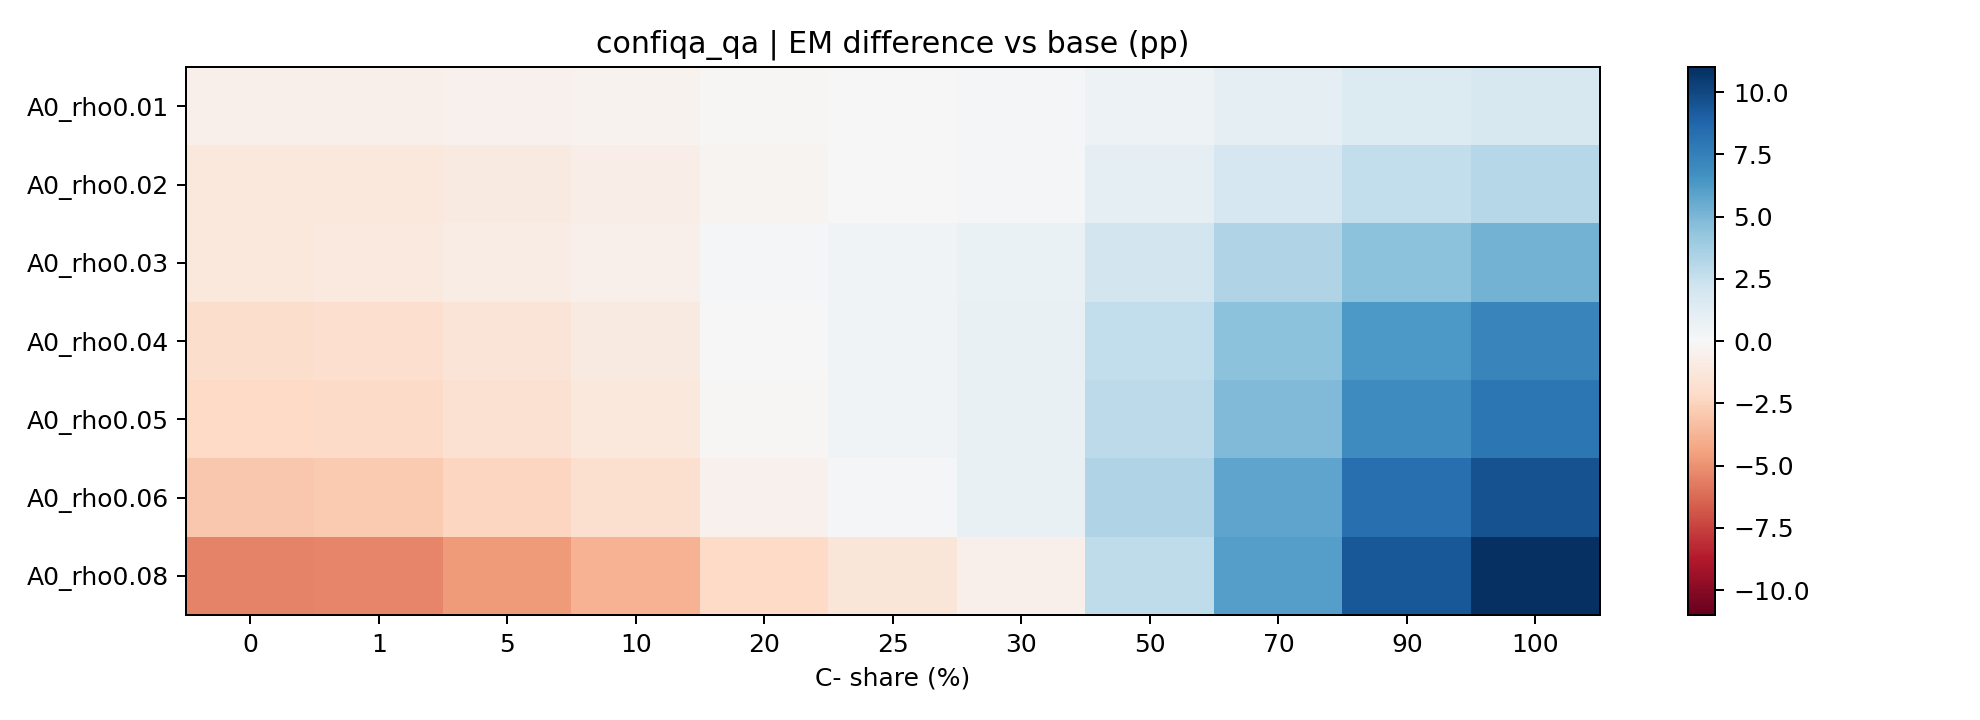

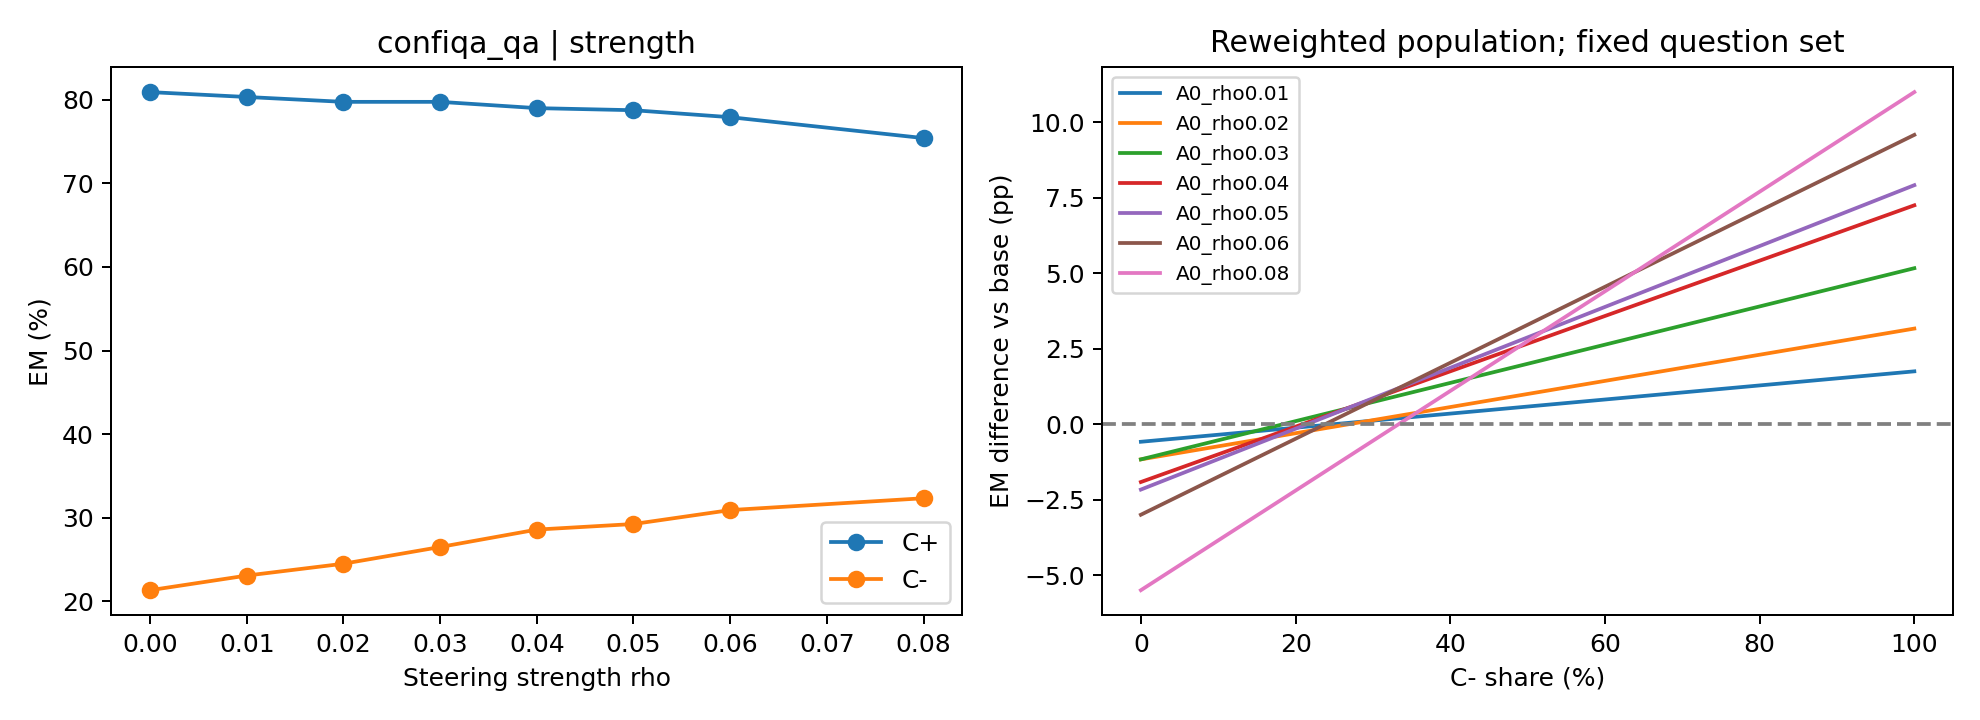

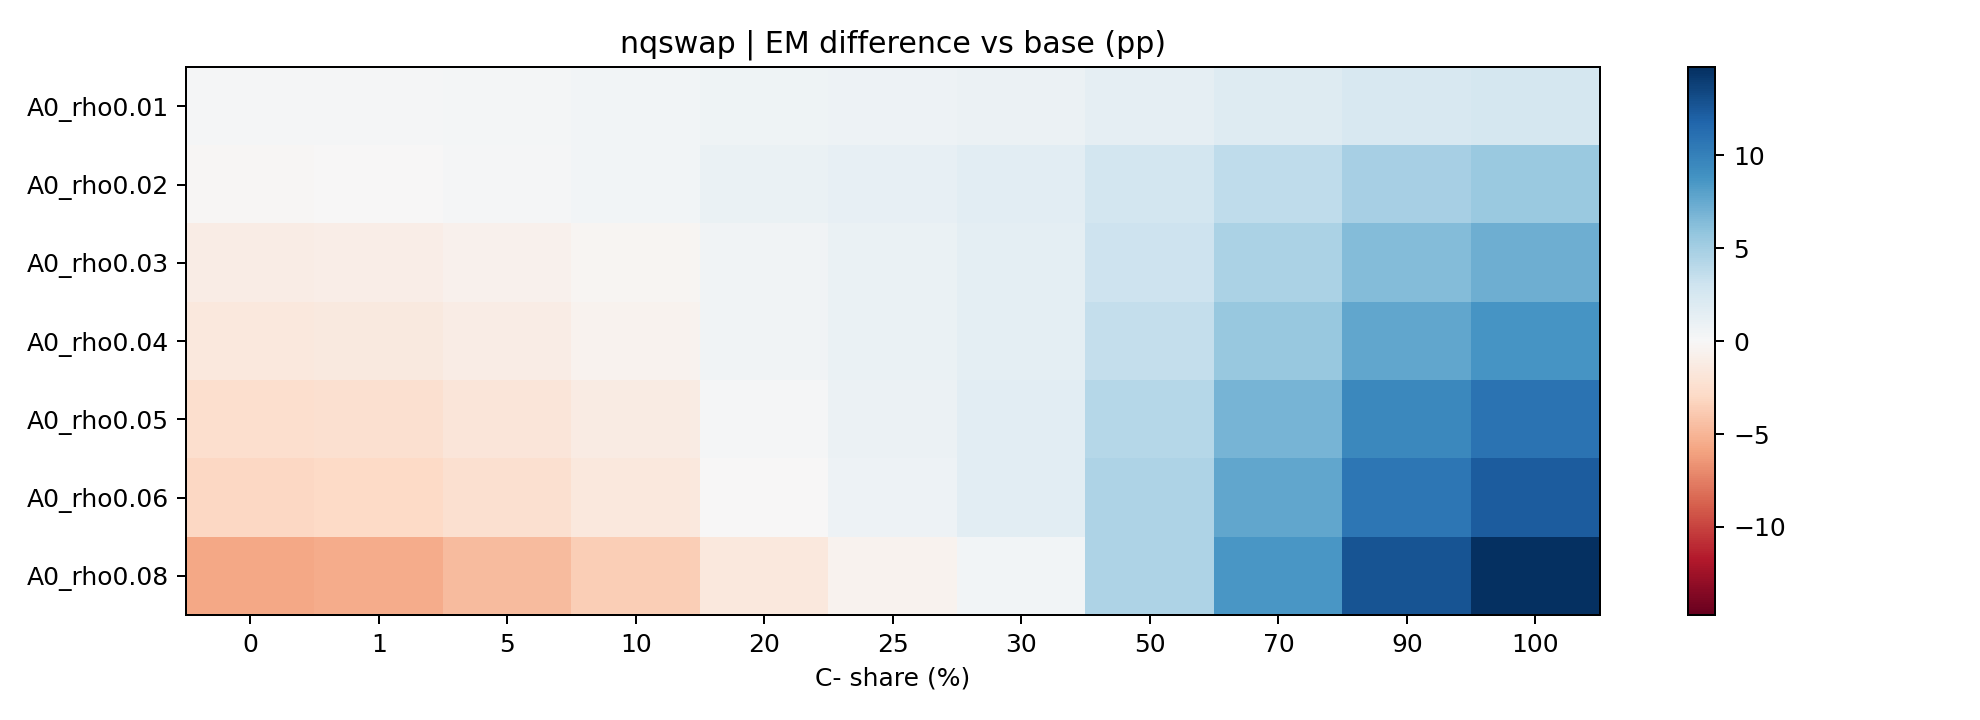

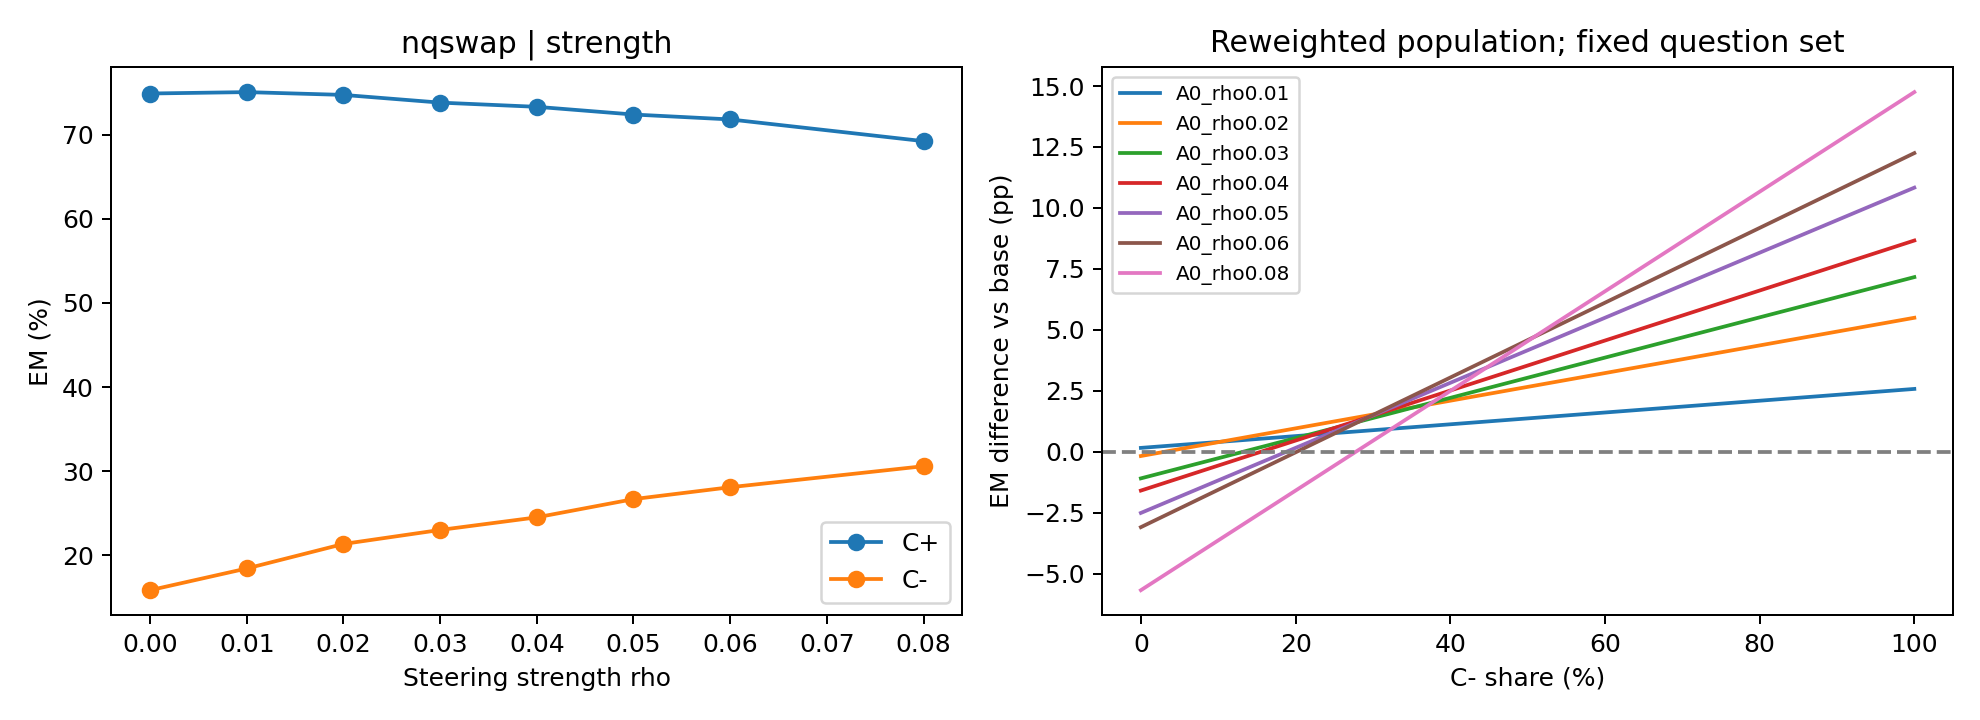

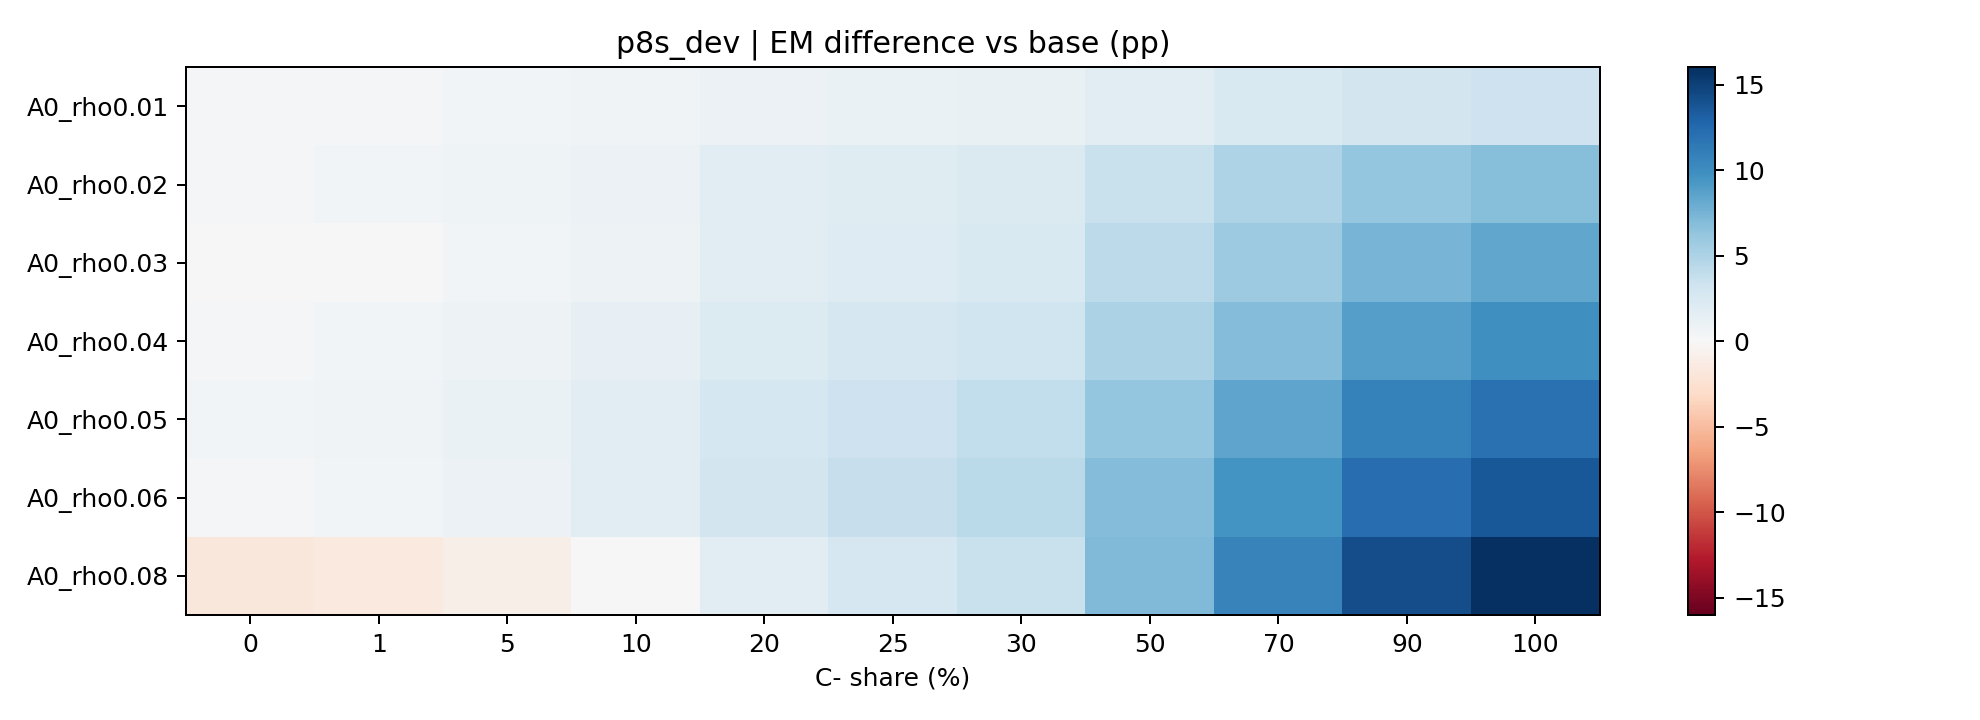

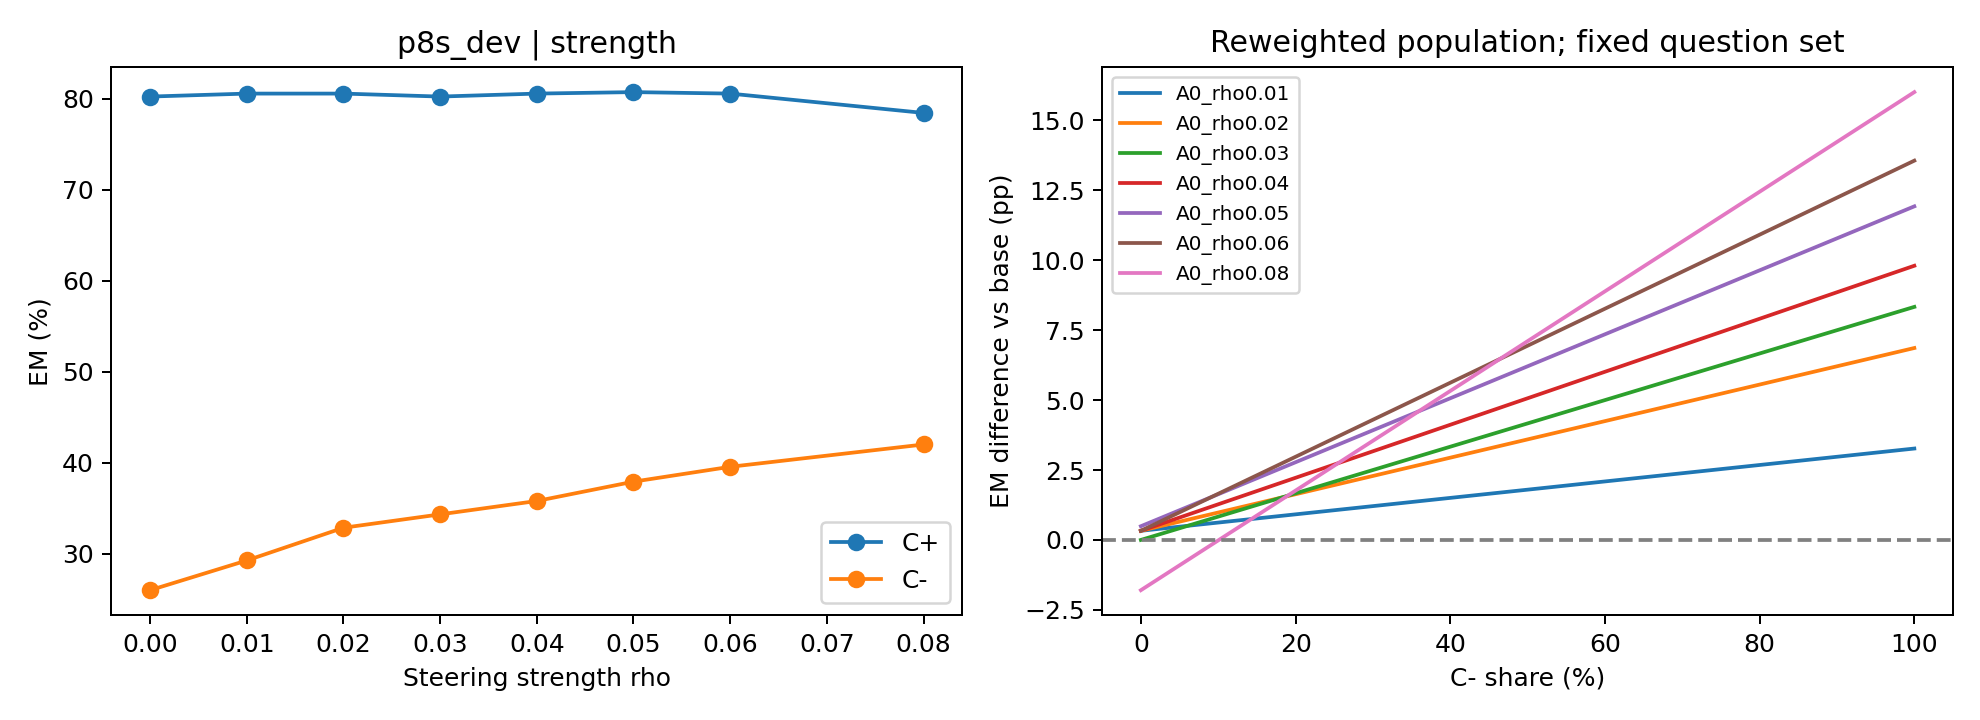

In [11]:
from IPython.display import display, Image
print(RUN)
m = pd.read_csv(RUN/'metrics.csv')
display(m[m.group.isin(['ALL','C+','C-'])])
display(pd.read_csv(RUN/'comparisons.csv'))
display(pd.read_csv(RUN/'mixture_metrics.csv'))
display(pd.read_csv(RUN/'break_even.csv'))
for p in sorted(RUN.glob('*.png')):
    display(Image(filename=str(p)))


## 해석
1. 강도를 줄일 때 C+ 손실이 감소하는지와 C− 이득이 남는지를 함께 본다. 단조로운 변화를 가정하지 않는다.
2. C− 비율별 ΔEM의 부호와 신뢰구간을 본다. 50:50 결과만으로 실제 서비스 성능을 주장하지 않는다.
3. CI는 각 강도·비율별 pointwise 95%이며, 다중 비교 및 강도 선택의 불확실성은 보정하지 않는다.
4. break_even.csv의 교차점은 점추정이며 보장된 안전 경계가 아니다.
5. C− 비율을 낮춰 전체 성능이 좋아져도 C+ 비열등 결과 자체는 바뀌지 않는다.
6. 새 강도를 선택하면 미사용 질문으로 최종 검증한다. 이번 실험은 타이밍 비교나 E16 재현이 아니다.


In [12]:
from pathlib import Path
# 현재 런타임의 RUN을 사용하거나 아래 완료된 결과 폴더를 직접 지정한다.
REPORT_RUN = Path(globals().get('RUN', '/content/drive/MyDrive/12주차_실험_다영/result/A3_sweep_20261004T145435712570Z'))
if not REPORT_RUN.is_dir():
    from google.colab import drive
    drive.mount('/content/drive')
assert REPORT_RUN.is_dir(), f'결과 폴더를 확인한다: {REPORT_RUN}'
FOCUS_RHOS = (.02, .03, .06)
print('읽는 위치:', REPORT_RUN)
print('그림 저장 위치:', REPORT_RUN / 'report_figures')


읽는 위치: /content/drive/MyDrive/12주차_실험_다영/result/A3_sweep_20261004T145435712570Z
그림 저장 위치: /content/drive/MyDrive/12주차_실험_다영/result/A3_sweep_20261004T145435712570Z/report_figures


In [14]:
# 보고용 시각화: 모델 실행 없이 기존 결과 CSV만 읽는다.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def make_report_figures(result_dir, metric='EM', focus_rhos=(.02,.03,.06)):
    result_dir=Path(result_dir)
    required=['metrics.csv','comparisons.csv','mixture_metrics.csv']
    for name in required:
        if not (result_dir/name).is_file():
            raise FileNotFoundError(f'{name}을 찾을 수 없다: {result_dir}')
    metrics=pd.read_csv(result_dir/'metrics.csv')
    comparisons=pd.read_csv(result_dir/'comparisons.csv')
    mixture=pd.read_csv(result_dir/'mixture_metrics.csv')
    if metric not in ['EM','F1']:raise ValueError('metric must be EM or F1')
    def rho(arm):
        return 0. if arm=='base' else float(arm.split('rho')[1])
    names={'p8s_dev':'p8s (development)','nqswap':'NQ-Swap','confiqa_qa':'ConFiQA-QA'}
    datasets=[n for n in names if n in set(metrics.dataset)]
    if not datasets:raise ValueError('No supported datasets')
    cp=comparisons[(comparisons.reference=='base')&(comparisons.metric==metric)&comparisons.group.isin(['ALL','C+','C-'])].copy()
    cp['rho']=cp.arm.map(rho)
    if cp.duplicated(['dataset','rho','group']).any():raise ValueError('Duplicate comparison rows')
    out=result_dir/'report_figures';out.mkdir(exist_ok=True)
    files=[]
    palette={.01:'#8c6d31',.02:'#0072b2',.03:'#009e73',.04:'#cc79a7',.05:'#e69f00',.06:'#d55e00',.08:'#6a51a3'}
    def save(fig,name):
        for ext in ['png','pdf']:
            p=out/f'{metric}_{name}.{ext}';fig.savefig(p,dpi=220,bbox_inches='tight',facecolor='white');files.append(p)
        plt.close(fig)
    def panels(title):
        fig,axes=plt.subplots(1,len(datasets),figsize=(5*len(datasets),4.8),squeeze=False,layout='constrained')
        fig.suptitle(title,fontsize=16,fontweight='bold')
        return fig,axes[0]
    def decorate(ax):
        ax.spines[['top','right']].set_visible(False);ax.grid(alpha=.18);ax.set_axisbelow(True)
    with plt.rc_context({'font.family':'DejaVu Sans','font.size':11,'axes.titlesize':12,'axes.labelsize':11,'legend.fontsize':9}):
        # 1. ALL / C+ / C- paired differences and pointwise confidence intervals.
        fig,axes=panels(f'{metric}: benefit and harm across steering strengths')
        for ax,ds in zip(axes,datasets):
            for group,color,marker in [('ALL','#555555','s'),('C+','#0072b2','o'),('C-','#d55e00','^')]:
                d=cp[(cp.dataset==ds)&(cp.group==group)].sort_values('rho')
                x=np.r_[0,d.rho.to_numpy()];y=np.r_[0,d.delta.to_numpy()]*100
                ax.plot(x,y,marker=marker,color=color,label=group,lw=2)
                ax.fill_between(x,np.r_[0,d.lo.to_numpy()]*100,np.r_[0,d.hi.to_numpy()]*100,color=color,alpha=.10)
            ax.axhline(0,color='#555555',ls='--',lw=1);ax.set(title=names[ds],xlabel='Steering strength (rho)',ylabel=f'{metric} change vs Base (pp)')
            ax.legend();decorate(ax)
        fig.supxlabel('Shading: pointwise 95% paired-bootstrap CI. ALL assumes 50% C-; no multiplicity adjustment.',fontsize=10)
        save(fig,'01_strength_effect')
        # 2. C+ forest: NI only applies to EM and requires lower confidence bound.
        fig,axes=panels(f'C+ {metric}: confidence intervals'+(' and non-inferiority' if metric=='EM' else ''))
        for ax,ds in zip(axes,datasets):
            d=cp[(cp.dataset==ds)&(cp.group=='C+')].sort_values('rho').reset_index(drop=True)
            for i,r in d.iterrows():
                passed=r.lo>=-.02;col=('#009e73' if passed else '#d55e00') if metric=='EM' else '#0072b2'
                ax.plot([r.lo*100,r.hi*100],[i,i],color=col,lw=2)
                ax.plot(r.delta*100,i,marker='o' if passed or metric!='EM' else 'X',color=col,ms=7)
            ax.axvline(0,color='#666666',lw=1)
            if metric=='EM':ax.axvline(-2,color='#777777',ls='--',lw=1.5)
            ax.set_yticks(range(len(d)),[f'{r:g}' for r in d.rho]);ax.invert_yaxis()
            ax.set(title=names[ds],xlabel=f'C+ {metric} change vs Base (pp)',ylabel='Steering strength (rho)');decorate(ax)
        if metric=='EM':
            axes[0].legend(handles=[Line2D([],[],color='#009e73',marker='o',ls='',label='NI met: lower CI >= -2 pp'),Line2D([],[],color='#d55e00',marker='X',ls='',label='NI not demonstrated')],loc='best')
        fig.supxlabel('Pointwise 95% CI. Non-inferiority does not mean zero harm; strength selection is exploratory.',fontsize=10)
        save(fig,'02_Cplus_intervals')
        # 3. Trade-off: label every rho; threshold here is point-estimate only.
        fig,axes=panels(f'{metric}: C+ / C- trade-off')
        for ax,ds in zip(axes,datasets):
            d=cp[cp.dataset==ds].pivot(index='rho',columns='group',values='delta').sort_index()*100
            ax.plot(d['C+'],d['C-'],color='#aaaaaa',lw=1,zorder=1)
            for r,row in d.iterrows():
                ax.scatter(row['C+'],row['C-'],s=55,color=palette.get(r,'#555555'),zorder=3)
                ax.annotate(f'{r:g}',(row['C+'],row['C-']),xytext=(5,6),textcoords='offset points',fontsize=9)
            ax.scatter([0],[0],marker='s',s=40,color='#555555');ax.annotate('Base',(0,0),xytext=(5,-13),textcoords='offset points',fontsize=9)
            ax.axvline(0,color='#777777',lw=1);ax.axhline(0,color='#777777',lw=1)
            ax.margins(x=.22,y=.18);ax.set(title=names[ds],xlabel=f'C+ {metric} change (pp)',ylabel=f'C- {metric} change (pp)');decorate(ax)
        fig.supxlabel('Upper-right is preferable. Points are estimates, not confidence-based safety decisions.',fontsize=10)
        save(fig,'03_tradeoff')
        # 4. Selected strengths: same fixed set reweighted, not new sampling.
        fig,axes=panels(f'{metric}: sensitivity to incorrect-context prevalence')
        for ax,ds in zip(axes,datasets):
            for r in focus_rhos:
                arm=f'A0_rho{r:g}';d=mixture[(mixture.dataset==ds)&(mixture.arm==arm)&(mixture.metric==metric)].sort_values('Cminus_ratio')
                if d.empty:continue
                color=palette.get(r,'#555555');x=d.Cminus_ratio.to_numpy()*100
                ax.plot(x,d.delta.to_numpy()*100,label=f'rho = {r:g}',color=color,lw=2)
                ax.fill_between(x,d.lo.to_numpy()*100,d.hi.to_numpy()*100,color=color,alpha=.10)
            ax.axhline(0,color='#555555',ls='--',lw=1);ax.set(title=names[ds],xlabel='C- share (%)',ylabel=f'Weighted {metric} change vs Base (pp)',xlim=(0,100))
            ax.legend();decorate(ax)
        fig.supxlabel('Fixed questions and conditional performance; only C-/C+ weights change. Pointwise 95% CI.',fontsize=10)
        save(fig,'04_prevalence')
    # Full export tables retain every strength; no automatic best-strength selection.
    table=cp[['dataset','rho','group','delta','lo','hi']].copy()
    for c in ['delta','lo','hi']:table[c+'_pp']=table[c]*100
    table.to_csv(out/f'{metric}_report_numbers.csv',index=False)
    if metric=='EM':
        flags=[]
        for (ds,r),a in cp.groupby(['dataset','rho']):
            a=a.set_index('group')
            if not {'ALL','C+','C-'}.issubset(a.index):continue
            flags.append(dict(dataset=ds,rho=r,ALL_improvement=bool(a.loc['ALL','lo']>0),Cminus_improvement=bool(a.loc['C-','lo']>0),Cplus_NI=bool(a.loc['C+','lo']>=-.02),all_three=bool(a.loc['ALL','lo']>0 and a.loc['C-','lo']>0 and a.loc['C+','lo']>=-.02)))
        pd.DataFrame(flags).to_csv(out/'EM_pointwise_criteria.csv',index=False)
    return files


In [15]:
from IPython.display import display, Image
for metric in ['EM', 'F1']:
    files = make_report_figures(REPORT_RUN, metric=metric, focus_rhos=FOCUS_RHOS)
    for path in files:
        if path.suffix == '.png':
            print(path.name)
            display(Image(filename=str(path)))
display(pd.read_csv(REPORT_RUN / 'report_figures' / 'EM_pointwise_criteria.csv'))
print('완료:', REPORT_RUN / 'report_figures')


Output hidden; open in https://colab.research.google.com to view.